# TFM - Detección y clasificación automática de ciberacoso en redes sociales mediante Machine Learning

## Notebook 01 - Análisis Exploratorio de Datos (EDA)

### Objetivo

El objetivo de este proyecto es analizar mensajes publicados en redes sociales y desarrollar posteriormente un modelo de Machine Learning capaz de clasificar automáticamente los textos en diferentes categorías relacionadas con el ciberacoso.

El proyecto aborda un problema de clasificación multiclase utilizando técnicas de Procesamiento del Lenguaje Natural (NLP) y Machine Learning.

Las categorías consideradas son:

- `age`: ciberacoso relacionado con la edad.
- `ethnicity`: ciberacoso relacionado con la etnia.
- `gender`: ciberacoso relacionado con el género.
- `religion`: ciberacoso relacionado con la religión.
- `other_cyberbullying`: otros tipos de ciberacoso.
- `not_cyberbullying`: contenido no clasificado como ciberacoso.

En este primer notebook se realizará el análisis exploratorio del dataset, prestando especial atención a:

- estructura y calidad de los datos;
- distribución de la variable objetivo;
- detección de duplicados e inconsistencias de etiquetado;
- características de los textos;
- análisis del vocabulario y patrones lingüísticos asociados a las distintas categorías.

Este análisis permitirá comprender las características del problema antes de realizar el procesamiento del texto y entrenar los modelos de Machine Learning.

## 1. Definición del problema

El ciberacoso constituye una problemática especialmente relevante en entornos digitales y redes sociales. El elevado volumen de contenido generado en estas plataformas dificulta que todos los mensajes potencialmente problemáticos puedan ser revisados manualmente.

Desde el punto de vista de Data Science, este problema puede abordarse mediante técnicas de Procesamiento del Lenguaje Natural (NLP) y Machine Learning que permitan analizar automáticamente el contenido textual y detectar patrones asociados a diferentes categorías de ciberacoso.

En este proyecto se plantea un problema de **clasificación supervisada multiclase**, donde cada mensaje debe ser asignado a una de seis categorías.

La pregunta principal que se pretende responder es:

> **¿Es posible utilizar técnicas de Procesamiento del Lenguaje Natural y Machine Learning clásico para identificar y clasificar automáticamente diferentes tipos de contenido relacionado con el ciberacoso a partir del texto de mensajes publicados en redes sociales?**

El modelo desarrollado pretende plantearse como una herramienta de apoyo para el análisis y priorización de grandes volúmenes de contenido, pudiendo resultar de interés en contextos de investigación, educación o intervención social.

No se plantea como un sistema capaz de determinar por sí mismo la existencia de una situación real de ciberacoso ni como sustituto de la valoración realizada por profesionales, ya que la identificación de estas situaciones puede requerir información contextual adicional que no está presente en el contenido textual.

## 2. Motivación del proyecto

La elección de esta temática responde al interés por explorar aplicaciones de la Ciencia de Datos y la Inteligencia Artificial en ámbitos de impacto social.

El uso creciente de redes sociales y plataformas digitales ha generado nuevas formas de interacción, pero también nuevos espacios en los que pueden producirse comportamientos ofensivos, discriminatorios o relacionados con el ciberacoso.

El análisis automático del lenguaje puede proporcionar herramientas complementarias para estudiar grandes cantidades de contenido y detectar patrones que serían difíciles de identificar mediante una revisión exclusivamente manual.

Por este motivo, el proyecto combina técnicas de Data Science, Procesamiento del Lenguaje Natural y Machine Learning con una problemática vinculada al ámbito social y educativo.

## 3. Descripción del dataset

Para el desarrollo del proyecto se utiliza el dataset **Cyberbullying Classification**, disponible públicamente en Kaggle.

El conjunto de datos contiene mensajes publicados en Twitter clasificados según diferentes tipos de ciberacoso.

El dataset original contiene **47.692 observaciones** y las siguientes variables:

- `tweet_text`: contenido textual del mensaje.
- `cyberbullying_type`: categoría asignada al mensaje y variable objetivo del problema de clasificación.

La variable objetivo presenta seis posibles categorías: `age`, `ethnicity`, `gender`, `religion`, `other_cyberbullying` y `not_cyberbullying`.

Antes de utilizar los datos para el entrenamiento de los modelos se realizará un análisis de su estructura, calidad y consistencia.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

pd.set_option("display.max_colwidth", 150)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# Descarga del dataset desde Kaggle

path = kagglehub.dataset_download(
    "andrewmvd/cyberbullying-classification"
)

file_path = os.path.join(
    path,
    "cyberbullying_tweets.csv"
)

print("Dataset descargado correctamente.")
print("Ruta:", file_path)

100%|██████████| 2.82M/2.82M [00:00<00:00, 126MB/s]

Extracting files...
Dataset descargado correctamente.
Ruta: /root/.cache/kagglehub/datasets/andrewmvd/cyberbullying-classification/versions/1/cyberbullying_tweets.csv


In [3]:
# Carga del dataset

df = pd.read_csv(file_path)

print("Dataset cargado correctamente.")
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Dataset cargado correctamente.
Número de observaciones: 47692
Número de variables: 2


In [4]:
df.head(10)

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was crapilicious! #mkr",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, but not too concerned about another angry dude on twitter.",not_cyberbullying
4,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.",not_cyberbullying
5,"@Raja5aab @Quickieleaks Yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.",not_cyberbullying
6,Itu sekolah ya bukan tempat bully! Ga jauh kaya neraka,not_cyberbullying
7,Karma. I hope it bites Kat on the butt. She is just nasty. #mkr,not_cyberbullying
8,@stockputout everything but mostly my priest,not_cyberbullying
9,Rebecca Black Drops Out of School Due to Bullying:,not_cyberbullying


In [5]:
print("INFORMACIÓN GENERAL DEL DATASET")
print("-" * 50)

df.info()

INFORMACIÓN GENERAL DEL DATASET
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [6]:
print("VALORES NULOS")
print("-" * 50)

nulos = pd.DataFrame({
    "Número de nulos": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean() * 100).round(2)
})

nulos

VALORES NULOS
--------------------------------------------------


,Número de nulos,Porcentaje (%)
tweet_text,0,0.0
cyberbullying_type,0,0.0


### Conclusiones de la exploración inicial

El dataset original contiene **47.692 observaciones y 2 variables**.

Las dos variables son de tipo textual (`object`): una contiene el mensaje publicado y la otra representa la categoría utilizada como variable objetivo.

No se detectan valores nulos en ninguna de las variables, por lo que no será necesario aplicar técnicas de imputación o eliminación de registros por ausencia de información.

El tamaño del conjunto de datos permite abordar el problema mediante técnicas de Procesamiento del Lenguaje Natural y Machine Learning sin requerir inicialmente estrategias específicas para conjuntos de datos de gran escala.

In [7]:
# ANÁLISIS DE DUPLICADOS Y CONSISTENCIA DE ETIQUETAS

# Contamos cuántas filas están completamente duplicadas.
# Esto significa que tanto el texto como la categoría son exactamente iguales.
duplicados_completos = df.duplicated().sum()

# Contamos cuántos textos están repetidos, aunque puedan tener etiquetas distintas.
# Este paso es importante porque un mismo mensaje podría aparecer más de una vez
# y no necesariamente con la misma categoría.
duplicados_texto = df.duplicated(subset=["tweet_text"]).sum()

print("ANÁLISIS DE DUPLICADOS")
print("-" * 50)
print(f"Filas completamente duplicadas: {duplicados_completos}")
print(f"Textos duplicados: {duplicados_texto}")

ANÁLISIS DE DUPLICADOS
--------------------------------------------------
Filas completamente duplicadas: 36
Textos duplicados: 1675


In [8]:
# COMPROBACIÓN DE TEXTOS CON ETIQUETAS CONTRADICTORIAS

# Agrupamos el dataset por el contenido exacto del mensaje.
# Para cada texto contamos cuántas categorías diferentes tiene asociadas.
categorias_por_texto = (
    df.groupby("tweet_text")["cyberbullying_type"]
      .nunique()
)

# Nos quedamos únicamente con los textos asociados
# a más de una categoría.
# Estos casos son problemáticos porque el mismo texto tendría
# dos o más respuestas correctas diferentes para el modelo.
textos_con_etiquetas_distintas = (
    categorias_por_texto[categorias_por_texto > 1]
)

print("TEXTOS ASOCIADOS A MÁS DE UNA CATEGORÍA")
print("-" * 50)
print(
    f"Número de textos con más de una etiqueta: "
    f"{len(textos_con_etiquetas_distintas)}"
)

TEXTOS ASOCIADOS A MÁS DE UNA CATEGORÍA
--------------------------------------------------
Número de textos con más de una etiqueta: 1639


In [9]:
from itertools import combinations
from collections import Counter

# Seleccionamos únicamente los registros cuyos textos
# presentan etiquetas contradictorias.
df_conflictos = df[
    df["tweet_text"].isin(textos_con_etiquetas_distintas.index)
]

# Para cada texto obtenemos la lista de categorías diferentes
# que tiene asociadas.
etiquetas_conflictivas = (
    df_conflictos
    .groupby("tweet_text")["cyberbullying_type"]
    .apply(lambda x: sorted(set(x)))
)

# Creamos un contador para registrar cuántas veces aparece
# cada combinación de etiquetas en conflicto.
pares_conflictivos = Counter()

# Algunos textos podrían tener más de dos etiquetas.
# combinations() genera todas las parejas posibles de categorías
# asociadas a cada texto.
for etiquetas in etiquetas_conflictivas:
    for par in combinations(etiquetas, 2):
        pares_conflictivos[par] += 1

# Convertimos los resultados a DataFrame
# para poder visualizarlos de forma ordenada.
tabla_conflictos = pd.DataFrame(
    [
        {
            "Categoría 1": par[0],
            "Categoría 2": par[1],
            "Número de conflictos": cantidad
        }
        for par, cantidad in pares_conflictivos.items()
    ]
).sort_values(
    "Número de conflictos",
    ascending=False
).reset_index(drop=True)

print("PRINCIPALES CONFLICTOS ENTRE ETIQUETAS")
print("-" * 60)

tabla_conflictos

PRINCIPALES CONFLICTOS ENTRE ETIQUETAS
------------------------------------------------------------


,Categoría 1,Categoría 2,Número de conflictos
0,not_cyberbullying,other_cyberbullying,1456
1,gender,other_cyberbullying,124
2,gender,not_cyberbullying,50
3,ethnicity,religion,4
4,ethnicity,not_cyberbullying,2
5,ethnicity,gender,1
6,gender,religion,1
7,not_cyberbullying,religion,1


### Interpretación de los duplicados y conflictos de etiquetado

Aunque inicialmente solo se detectaron **36 filas completamente duplicadas**, el análisis de la variable textual mostró que existían **1.675 textos repetidos**.

Al profundizar en estos casos se identificaron **1.639 textos asociados a más de una categoría**, lo que supone una inconsistencia de etiquetado.

La mayor parte de los conflictos se concentró entre las categorías `not_cyberbullying` y `other_cyberbullying`, con **1.456 casos**.

Esto indica que el principal problema de consistencia del dataset no se encuentra entre las categorías específicas como edad, religión o etnia, sino principalmente en la frontera entre contenido clasificado como ciberacoso genérico y contenido clasificado como no ciberacoso.

Dado que no se dispone de información externa suficiente para determinar cuál de las etiquetas contradictorias es la correcta, se optará por eliminar estos textos antes del entrenamiento del modelo, evitando introducir ruido en el aprendizaje supervisado.

## 6. Limpieza y preparación inicial del dataset

Tras analizar los duplicados y las inconsistencias de etiquetado, se establece la siguiente estrategia de limpieza:

1. Eliminar todos los registros correspondientes a textos asociados a más de una categoría, ya que no es posible determinar de forma objetiva cuál de las etiquetas contradictorias es la correcta.
2. Eliminar posteriormente los textos duplicados restantes, conservando una única observación de cada mensaje.
3. Comprobar nuevamente la calidad y distribución del dataset resultante.

Esta estrategia prioriza la consistencia de las etiquetas frente a la conservación del máximo número posible de observaciones.

In [10]:
# ----------------------------------------------------------
# LIMPIEZA DEL DATASET
# ----------------------------------------------------------

# Guardamos una copia del dataset original.
# Esto nos permite conservar los datos sin modificar por si posteriormente
# necesitamos realizar alguna comparación con el dataset inicial.
df_original = df.copy()


# Creamos un conjunto (set) con todos los textos que anteriormente
# hemos identificado como conflictivos.
#
# Un texto se considera conflictivo cuando aparece asociado
# a más de una categoría diferente.
textos_conflictivos = set(
    textos_con_etiquetas_distintas.index
)


# Eliminamos del dataset TODOS los registros cuyo texto
# se encuentre dentro del conjunto de textos conflictivos.
#
# isin() comprueba si cada tweet está dentro de textos_conflictivos.
# El símbolo ~ invierte el resultado:
#
#     está en textos_conflictivos      -> True
#     ~True                            -> False -> se elimina
#
#     no está en textos_conflictivos   -> False
#     ~False                           -> True  -> se conserva
#
# Utilizamos .copy() para crear un DataFrame independiente.
df = df[
    ~df["tweet_text"].isin(textos_conflictivos)
].copy()


# Después de eliminar los textos conflictivos todavía pueden existir
# mensajes repetidos que tengan la MISMA etiqueta.
#
# En esos casos no existe contradicción, pero tampoco necesitamos
# varias copias idénticas del mismo mensaje.
#
# Conservamos únicamente la primera aparición de cada texto.
df = df.drop_duplicates(
    subset=["tweet_text"],
    keep="first"
)


# Reiniciamos el índice porque, después de eliminar registros,
# los índices originales ya no son consecutivos.
#
# drop=True evita que el índice antiguo se convierta
# en una nueva columna del DataFrame.
df = df.reset_index(drop=True)


# Calculamos el impacto de la limpieza.
registros_originales = len(df_original)
registros_finales = len(df)
registros_eliminados = registros_originales - registros_finales

porcentaje_eliminado = (
    registros_eliminados / registros_originales
) * 100


print("RESULTADO DE LA LIMPIEZA")
print("-" * 50)

print(f"Registros originales: {registros_originales}")
print(f"Registros finales: {registros_finales}")
print(f"Registros eliminados: {registros_eliminados}")
print(f"Porcentaje eliminado: {porcentaje_eliminado:.2f}%")

RESULTADO DE LA LIMPIEZA
--------------------------------------------------
Registros originales: 47692
Registros finales: 44378
Registros eliminados: 3314
Porcentaje eliminado: 6.95%


In [11]:
# ----------------------------------------------------------
# CONTROL DE CALIDAD DEL DATASET LIMPIO
# ----------------------------------------------------------

# Comprobamos que después de la limpieza:
# - no existen valores nulos;
# - no existen textos duplicados;
# - ningún texto tiene más de una etiqueta;
# - seguimos conservando las seis categorías originales.

nulos_finales = df.isnull().sum().sum()

duplicados_finales = (
    df.duplicated(subset=["tweet_text"]).sum()
)

conflictos_finales = (
    df.groupby("tweet_text")["cyberbullying_type"]
      .nunique()
      .gt(1)
      .sum()
)

numero_categorias = (
    df["cyberbullying_type"].nunique()
)


print("CONTROL FINAL DE CALIDAD")
print("-" * 50)

print(f"Valores nulos: {nulos_finales}")
print(f"Textos duplicados: {duplicados_finales}")
print(f"Textos con etiquetas contradictorias: {conflictos_finales}")
print(f"Número de categorías: {numero_categorias}")
print(f"Dimensiones finales: {df.shape}")

CONTROL FINAL DE CALIDAD
--------------------------------------------------
Valores nulos: 0
Textos duplicados: 0
Textos con etiquetas contradictorias: 0
Número de categorías: 6
Dimensiones finales: (44378, 2)


In [12]:
# ----------------------------------------------------------
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ----------------------------------------------------------

# Calculamos el número de observaciones de cada categoría.
conteo_clases = (
    df["cyberbullying_type"]
    .value_counts()
)

# Calculamos también qué porcentaje del dataset
# representa cada categoría.
porcentaje_clases = (
    df["cyberbullying_type"]
    .value_counts(normalize=True) * 100
)

# Unimos ambos resultados en una misma tabla.
distribucion_clases = pd.DataFrame({
    "Número de observaciones": conteo_clases,
    "Porcentaje (%)": porcentaje_clases.round(2)
})

print("DISTRIBUCIÓN DE LAS CATEGORÍAS")
print("-" * 50)

distribucion_clases

DISTRIBUCIÓN DE LAS CATEGORÍAS
--------------------------------------------------


,Número de observaciones,Porcentaje (%)
cyberbullying_type,,
age,7992,18.01
religion,7991,18.01
ethnicity,7952,17.92
gender,7772,17.51
not_cyberbullying,6428,14.48
other_cyberbullying,6243,14.07


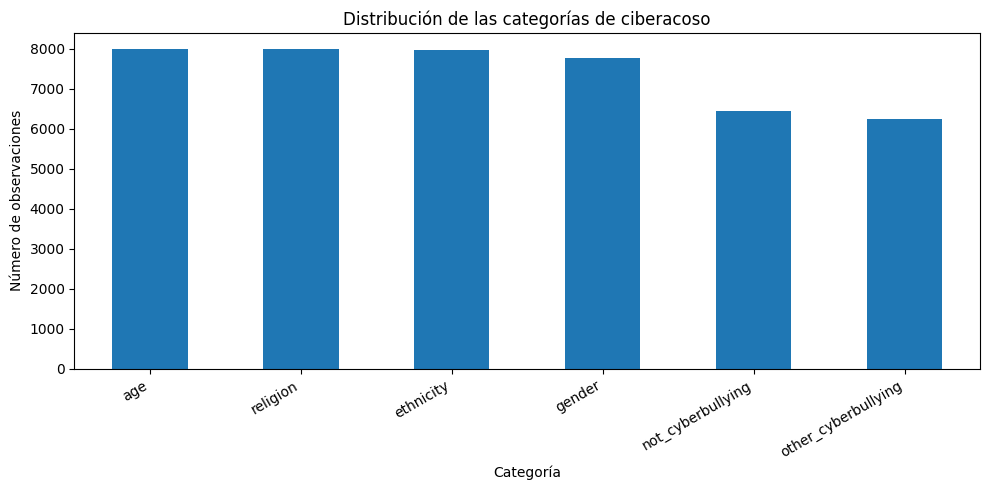

In [13]:
# Representamos gráficamente el número de observaciones
# disponibles para cada categoría.

conteo_clases.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribución de las categorías de ciberacoso")
plt.xlabel("Categoría")
plt.ylabel("Número de observaciones")

# Rotamos ligeramente las etiquetas para facilitar su lectura.
plt.xticks(rotation=30, ha="right")

# Ajustamos automáticamente los márgenes del gráfico.
plt.tight_layout()

plt.show()

### Conclusiones del proceso de limpieza

El proceso de limpieza redujo el dataset desde **47.692 hasta 44.378 observaciones**, lo que supone la eliminación de **3.314 registros (6,95 %)**.

La reducción se debe principalmente a la eliminación de textos asociados a etiquetas contradictorias y, posteriormente, a la eliminación de mensajes duplicados.

Tras la limpieza se comprobó que el dataset no contiene valores nulos, textos duplicados ni mensajes asociados a categorías contradictorias.

La distribución de la variable objetivo continúa siendo razonablemente equilibrada. Las seis categorías representan aproximadamente entre el **14 % y el 18 %** de las observaciones.

Por este motivo, no se considera necesario aplicar técnicas específicas de balanceo de clases. En la posterior división de los datos se utilizará una partición estratificada para mantener una distribución similar de las categorías entre los conjuntos de entrenamiento y prueba.

## 9. Análisis de las características de los textos

Una vez validada la calidad del dataset y analizada la distribución de la variable objetivo, se estudian algunas características básicas de los mensajes.

Antes de analizar el vocabulario resulta útil conocer la longitud de los textos, ya que pueden existir diferencias entre las distintas categorías.

Para ello se analizarán dos medidas:

- **Número de caracteres:** longitud total del mensaje.
- **Número de palabras:** cantidad aproximada de palabras que contiene cada mensaje.

Estas variables se utilizan únicamente con fines exploratorios en esta fase y permitirán conocer mejor la estructura del contenido textual.

In [14]:
# ----------------------------------------------------------
# CREACIÓN DE VARIABLES DE LONGITUD DEL TEXTO
# ----------------------------------------------------------

# Creamos una nueva variable llamada "num_caracteres".
#
# .str.len() calcula la longitud de cada texto, contando
# todos sus caracteres: letras, números, espacios,
# signos de puntuación, hashtags, etc.
df["num_caracteres"] = (
    df["tweet_text"]
    .str.len()
)


# Creamos una segunda variable llamada "num_palabras".
#
# .str.split() divide cada texto utilizando los espacios
# como separadores y genera una lista de elementos.
#
# Después .str.len() cuenta cuántos elementos contiene
# esa lista, obteniendo una aproximación al número
# de palabras del mensaje.
df["num_palabras"] = (
    df["tweet_text"]
    .str.split()
    .str.len()
)


# Mostramos algunos ejemplos para comprobar
# que las nuevas variables se han creado correctamente.
df[
    [
        "tweet_text",
        "cyberbullying_type",
        "num_caracteres",
        "num_palabras"
    ]
].head()

,tweet_text,cyberbullying_type,num_caracteres,num_palabras
0,"In other words #katandandre, your food was crapilicious! #mkr",not_cyberbullying,61,9
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,not_cyberbullying,115,14
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,not_cyberbullying,60,9
3,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.",not_cyberbullying,103,18
4,"@Raja5aab @Quickieleaks Yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.",not_cyberbullying,131,23


In [15]:
# ----------------------------------------------------------
# ESTADÍSTICAS GENERALES DE LONGITUD
# ----------------------------------------------------------

# describe() calcula diferentes estadísticas descriptivas:
#
# count -> número de observaciones
# mean  -> media
# std   -> desviación estándar
# min   -> valor mínimo
# 25%   -> primer cuartil
# 50%   -> mediana
# 75%   -> tercer cuartil
# max   -> valor máximo
#
# Aplicamos describe() únicamente a las dos variables
# de longitud que acabamos de crear.

df[
    ["num_caracteres", "num_palabras"]
].describe().round(2)

,num_caracteres,num_palabras
count,44378.00,44378.00
mean,140.09,24.44
std,86.48,15.63
min,1.00,1.00
25%,81.00,14.00
50%,127.00,21.00
75%,194.00,34.00
max,5018.00,790.00


In [16]:
# ----------------------------------------------------------
# LONGITUD MEDIA DE LOS MENSAJES POR CATEGORÍA
# ----------------------------------------------------------

# Agrupamos los mensajes según su categoría de ciberacoso.
#
# Para cada categoría calculamos la media de:
# - número de caracteres;
# - número de palabras.
#
# Esto nos permitirá comprobar si existen diferencias
# en la extensión de los mensajes entre las distintas clases.

longitud_por_categoria = (
    df.groupby("cyberbullying_type")
      [["num_caracteres", "num_palabras"]]
      .mean()
      .round(2)
      .sort_values(
          "num_palabras",
          ascending=False
      )
)

longitud_por_categoria

,num_caracteres,num_palabras
cyberbullying_type,,
religion,198.05,33.43
age,173.54,32.37
ethnicity,139.33,24.89
gender,137.93,23.83
other_cyberbullying,85.95,14.15
not_cyberbullying,82.57,13.55


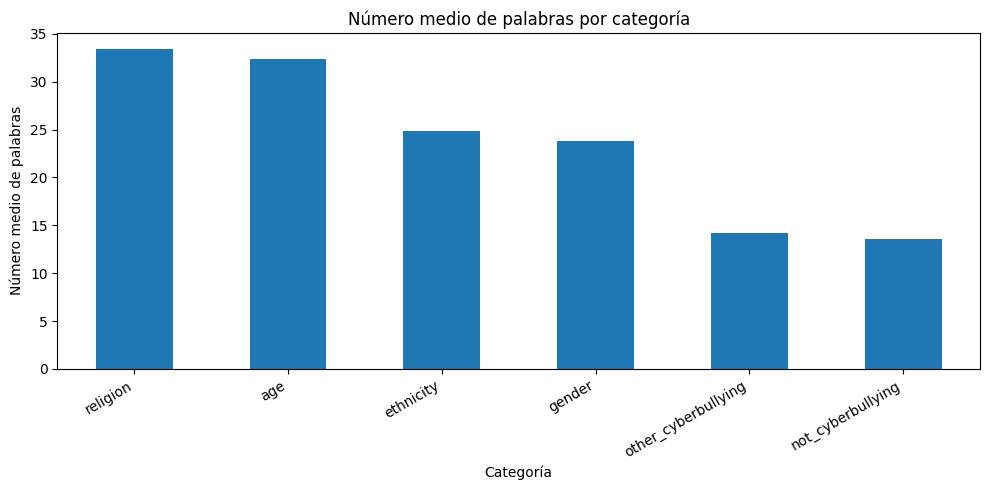

In [17]:
# ----------------------------------------------------------
# LONGITUD MEDIA DE LOS MENSAJES POR CATEGORÍA
# ----------------------------------------------------------

# Ordenamos las categorías según el número medio de palabras.
# Esto facilita visualmente la comparación entre ellas.
media_palabras = (
    df.groupby("cyberbullying_type")["num_palabras"]
      .mean()
      .sort_values(ascending=False)
)


# Creamos un gráfico de barras.
media_palabras.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Número medio de palabras por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número medio de palabras")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

### Interpretación de la longitud de los mensajes

El análisis muestra diferencias en la longitud media de los mensajes entre las distintas categorías.

Las categorías `religion` y `age` presentan los textos más extensos, con aproximadamente **33,43 y 32,37 palabras de media**, respectivamente.

Las categorías `ethnicity` y `gender` presentan valores intermedios, mientras que `other_cyberbullying` y `not_cyberbullying` contienen los mensajes más cortos, con aproximadamente **14,15 y 13,55 palabras de media**.

Estos resultados indican que, dentro de este dataset, la longitud del mensaje presenta diferencias según la categoría asignada. Por este motivo, variables relacionadas con la longitud del texto podrían evaluarse posteriormente como posibles características adicionales durante la fase de modelado.

Estas diferencias deben interpretarse como características del conjunto de datos analizado y no como patrones universales del ciberacoso.

## 10. Análisis exploratorio del vocabulario

El contenido textual constituye la principal fuente de información del problema de clasificación.

Por este motivo, se realiza un análisis exploratorio del vocabulario con el objetivo de identificar palabras y expresiones frecuentes dentro de las diferentes categorías.

Para que este análisis resulte más informativo se creará una versión normalizada de los textos destinada exclusivamente al análisis exploratorio. Esta transformación no implica que el mismo procesamiento vaya a utilizarse necesariamente durante el entrenamiento de los modelos.

Posteriormente se distinguirá entre dos conceptos:

- **Términos frecuentes:** palabras que aparecen muchas veces dentro de una categoría.
- **Términos discriminativos:** palabras o expresiones que aportan información para diferenciar una categoría de las demás.

Una palabra muy frecuente no tiene por qué ser útil para la clasificación si aparece con una frecuencia similar en todas las categorías.

In [18]:
# ----------------------------------------------------------
# PALABRAS MÁS FRECUENTES SIN LIMPIEZA
# ----------------------------------------------------------

from collections import Counter

# Unimos todos los mensajes del dataset en un único texto.
#
# str.lower() transforma todas las palabras a minúsculas
# para evitar considerar "The" y "the" como palabras distintas.
texto_completo = " ".join(
    df["tweet_text"].str.lower()
)

# Separamos el texto utilizando los espacios.
palabras_sin_limpiar = texto_completo.split()

# Counter cuenta cuántas veces aparece cada elemento.
contador_sin_limpiar = Counter(
    palabras_sin_limpiar
)

# Mostramos las 20 palabras más frecuentes.
contador_sin_limpiar.most_common(20)

[('the', 29634),
 ('a', 23682),
 ('to', 22147),
 ('and', 20972),
 ('i', 18957),
 ('you', 16758),
 ('of', 14735),
 ('in', 14359),
 ('is', 13192),
 ('that', 10463),
 ('are', 8676),
 ('for', 8219),
 ('school', 7073),
 ('not', 6750),
 ('it', 6416),
 ('me', 6413),
 ('my', 6402),
 ('was', 6297),
 ('but', 5876),
 ('this', 5714)]

In [19]:
# ----------------------------------------------------------
# PREPARACIÓN DE RECURSOS PARA EL ANÁLISIS DE VOCABULARIO
# ----------------------------------------------------------

import re
import nltk

from nltk.corpus import stopwords

# Descargamos la lista de palabras vacías en inglés
# incluida en la librería NLTK.
nltk.download(
    "stopwords",
    quiet=True
)

# Convertimos la lista a un conjunto (set).
#
# Los sets permiten comprobar de forma muy rápida
# si una palabra pertenece o no a la colección.
stop_words = set(
    stopwords.words("english")
)

print(
    f"Número de stopwords en inglés: "
    f"{len(stop_words)}"
)

Número de stopwords en inglés: 198


In [26]:
# ----------------------------------------------------------
# FUNCIÓN DE NORMALIZACIÓN PARA EL EDA DE VOCABULARIO
# ----------------------------------------------------------

def limpiar_texto_eda(texto):

    # 1. Convertimos todo el texto a minúsculas.
    #
    # De esta forma:
    # "People", "PEOPLE" y "people"
    # pasan a considerarse la misma palabra.
    texto = texto.lower()


    # 2. Eliminamos URLs.
    #
    # Las direcciones web pueden generar muchos elementos
    # diferentes que aportan poco al análisis del vocabulario.
    texto = re.sub(
        r"http\S+|www\S+",
        " ",
        texto
    )


    # 3. Eliminamos menciones de usuarios de Twitter.
    #
    # Por ejemplo, una mención como "usuario123"
    # precedida por el símbolo de arroba.
    #
    # Los nombres concretos de usuarios pueden ser frecuentes,
    # pero no queremos interpretarlos como patrones lingüísticos
    # generales del ciberacoso.
    texto = re.sub(
        r"@\w+",
        " ",
        texto
    )


    # 4. Eliminamos únicamente el símbolo de los hashtags,
    # pero conservamos la palabra que contiene el hashtag.
    #
    # Por ejemplo:
    # "#bullying" se transforma en "bullying".
    #
    # La palabra puede contener información útil.
    texto = texto.replace("#", "")


    # 5. Conservamos únicamente letras y espacios.
    #
    # Los números y signos de puntuación se sustituyen
    # por espacios.
    texto = re.sub(
        r"[^a-z\s]",
        " ",
        texto
    )


    # 6. Dividimos el texto en palabras.
    palabras = texto.split()


    # 7. Eliminamos las stopwords inglesas y
    # las palabras formadas por un único carácter.
    palabras = [
        palabra
        for palabra in palabras
        if palabra not in stop_words
        and len(palabra) > 1
    ]


    # 8. Volvemos a unir las palabras para obtener
    # el texto normalizado.
    return " ".join(palabras)

In [24]:
# Aplicamos la función a todos los mensajes.
#
# Creamos una NUEVA columna para conservar también
# el texto original sin modificar.

df["texto_eda"] = (
    df["tweet_text"]
    .apply(limpiar_texto_eda)
)


# Comparamos algunos ejemplos.
df[
    [
        "tweet_text",
        "texto_eda",
        "cyberbullying_type"
    ]
].head(10)

,tweet_text,texto_eda,cyberbullying_type
0,"In other words #katandandre, your food was crapilicious! #mkr",words katandandre food crapilicious mkr,not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,aussietv white mkr theblock imacelebrityau today sunrise studio neighbours wonderlandten etc,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,classy whore red velvet cupcakes,not_cyberbullying
3,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.",isis account pretending kurdish account like islam lies,not_cyberbullying
4,"@Raja5aab @Quickieleaks Yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.",yes test god good bad indifferent weird whatever proves gods existence,not_cyberbullying
5,Itu sekolah ya bukan tempat bully! Ga jauh kaya neraka,itu sekolah ya bukan tempat bully ga jauh kaya neraka,not_cyberbullying
6,Karma. I hope it bites Kat on the butt. She is just nasty. #mkr,karma hope bites kat butt nasty mkr,not_cyberbullying
7,Rebecca Black Drops Out of School Due to Bullying:,rebecca black drops school due bullying,not_cyberbullying
8,@Jord_Is_Dead http://t.co/UsQInYW5Gn,,not_cyberbullying
9,The Bully flushes on KD http://twitvid.com/A2TNP,bully flushes kd,not_cyberbullying


In [27]:
df[
    [
        "tweet_text",
        "texto_eda",
        "cyberbullying_type"
    ]
].head(5)

,tweet_text,texto_eda,cyberbullying_type
0,"In other words #katandandre, your food was crapilicious! #mkr",words katandandre food crapilicious mkr,not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,aussietv white mkr theblock imacelebrityau today sunrise studio neighbours wonderlandten etc,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,classy whore red velvet cupcakes,not_cyberbullying
3,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.",isis account pretending kurdish account like islam lies,not_cyberbullying
4,"@Raja5aab @Quickieleaks Yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.",yes test god good bad indifferent weird whatever proves gods existence,not_cyberbullying


In [28]:
# ----------------------------------------------------------
# PALABRAS MÁS FRECUENTES POR CATEGORÍA
# ----------------------------------------------------------

from collections import Counter

def palabras_mas_frecuentes(dataframe, categoria, n=15):
    """
    Devuelve las n palabras más frecuentes de una categoría.

    Parámetros:
    - dataframe: conjunto de datos que contiene los textos.
    - categoria: categoría de ciberacoso que queremos analizar.
    - n: número de palabras que queremos mostrar.
    """

    # Seleccionamos únicamente los textos pertenecientes
    # a la categoría indicada.
    textos_categoria = dataframe.loc[
        dataframe["cyberbullying_type"] == categoria,
        "texto_eda"
    ]

    # Unimos todos los textos de esa categoría
    # en una única cadena.
    texto_unido = " ".join(textos_categoria)

    # Dividimos la cadena en palabras individuales.
    palabras = texto_unido.split()

    # Contamos cuántas veces aparece cada palabra.
    contador = Counter(palabras)

    # Devolvemos las n palabras más frecuentes.
    return contador.most_common(n)

In [29]:
# Lista de categorías del problema
categorias = [
    "age",
    "ethnicity",
    "gender",
    "religion",
    "other_cyberbullying",
    "not_cyberbullying"
]

# Mostramos las 15 palabras más frecuentes de cada categoría.
for categoria in categorias:

    print("\n" + "=" * 60)
    print(f"PALABRAS MÁS FRECUENTES - {categoria.upper()}")
    print("=" * 60)

    print(
        palabras_mas_frecuentes(
            df,
            categoria,
            n=15
        )
    )


PALABRAS MÁS FRECUENTES - AGE
[('school', 8299), ('high', 5081), ('bullied', 4393), ('bully', 2756), ('girl', 2358), ('girls', 2341), ('like', 1857), ('bullies', 1639), ('one', 956), ('people', 934), ('got', 827), ('middle', 788), ('get', 684), ('would', 682), ('amp', 554)]

PALABRAS MÁS FRECUENTES - ETHNICITY
[('fuck', 5223), ('dumb', 5214), ('nigger', 4465), ('ass', 2280), ('black', 2108), ('white', 1528), ('niggers', 1322), ('rt', 1221), ('people', 1177), ('obama', 1152), ('like', 1007), ('ur', 998), ('one', 996), ('bitch', 945), ('called', 904)]

PALABRAS MÁS FRECUENTES - GENDER
[('rape', 4300), ('gay', 3877), ('jokes', 3455), ('joke', 1916), ('rt', 1227), ('people', 1003), ('call', 987), ('sexist', 980), ('like', 926), ('women', 912), ('bitch', 864), ('female', 832), ('funny', 678), ('make', 629), ('men', 619)]

PALABRAS MÁS FRECUENTES - RELIGION
[('muslims', 2461), ('muslim', 2405), ('idiot', 1775), ('christian', 1537), ('idiots', 1347), ('islamic', 1285), ('like', 1239), ('isla

In [30]:
# ----------------------------------------------------------
# AMPLIACIÓN DE STOPWORDS ESPECÍFICAS DEL DATASET
# ----------------------------------------------------------

# Durante el análisis exploratorio hemos identificado algunos
# términos muy frecuentes que proceden del funcionamiento
# de Twitter o de la codificación del texto y que no aportan
# contenido semántico relevante para nuestro análisis.
#
# "rt"  -> indicador habitual de retweet.
# "amp" -> residuo frecuente de la codificación HTML "&amp;".
#
# Los incorporamos a las stopwords utilizadas exclusivamente
# para el análisis exploratorio del vocabulario.

stop_words.update([
    "rt",
    "amp"
])

print(
    "Stopwords actualizadas:",
    len(stop_words)
)

Stopwords actualizadas: 200


In [31]:
# Volvemos a generar la columna de texto normalizado
# utilizando la lista actualizada de stopwords.

df["texto_eda"] = (
    df["tweet_text"]
    .apply(limpiar_texto_eda)
)

print("Textos normalizados nuevamente.")

Textos normalizados nuevamente.


In [32]:
from sklearn.feature_extraction.text import CountVectorizer

In [34]:
# ----------------------------------------------------------
# BIGRAMAS MÁS FRECUENTES POR CATEGORÍA
# ----------------------------------------------------------

def bigramas_mas_frecuentes(dataframe, categoria, n=10):

    # Seleccionamos los textos normalizados
    # correspondientes únicamente a la categoría indicada.
    textos = dataframe.loc[
        dataframe["cyberbullying_type"] == categoria,
        "texto_eda"
    ]

    # CountVectorizer transforma los textos en una
    # representación numérica basada en frecuencia.
    #
    # ngram_range=(2, 2) indica que queremos analizar
    # exclusivamente combinaciones de DOS palabras consecutivas.
    vectorizador = CountVectorizer(
        ngram_range=(2, 2)
    )

    # fit_transform() identifica todos los bigramas
    # existentes y cuenta sus apariciones en cada mensaje.
    matriz = vectorizador.fit_transform(textos)

    # Sumamos las apariciones de cada bigrama
    # en todos los mensajes de la categoría.
    frecuencias = np.asarray(
        matriz.sum(axis=0)
    ).ravel()

    # Recuperamos el nombre de cada bigrama.
    bigramas = (
        vectorizador.get_feature_names_out()
    )

    # Creamos una tabla con el bigrama
    # y su frecuencia total.
    resultado = pd.DataFrame({
        "bigrama": bigramas,
        "frecuencia": frecuencias
    })

    # Ordenamos de mayor a menor frecuencia
    # y devolvemos únicamente los n primeros.
    return (
        resultado
        .sort_values(
            "frecuencia",
            ascending=False
        )
        .head(n)
        .reset_index(drop=True)
    )

In [35]:
for categoria in categorias:

    print("\n" + "=" * 60)
    print(
        f"BIGRAMAS MÁS FRECUENTES - "
        f"{categoria.upper()}"
    )
    print("=" * 60)

    display(
        bigramas_mas_frecuentes(
            df,
            categoria,
            n=10
        )
    )


BIGRAMAS MÁS FRECUENTES - AGE


,bigrama,frecuencia
0,high school,4643
1,bullied high,1343
2,girls bullied,761
3,school bully,759
4,girl bullied,631
5,middle school,602
6,school bullies,445
7,got bullied,375
8,girls high,243
9,school bullied,237



BIGRAMAS MÁS FRECUENTES - ETHNICITY


,bigrama,frecuencia
0,dumb ass,1546
1,ass nigger,1226
2,fuck obama,1001
3,obama dumb,985
4,dumb nigger,964
5,dumb fuck,888
6,fuck dumb,691
7,black people,353
8,white people,244
9,dumb niggers,242



BIGRAMAS MÁS FRECUENTES - GENDER


...

,bigrama,frecuencia
0,islamic terrorism,877
1,christian woman,827
2,radical islamic,215
3,idiots like,125
4,support radical,111
5,good christian,107
6,radical islam,90
7,woman right,82
8,non muslims,82
9,people like,71



BIGRAMAS MÁS FRECUENTES - OTHER_CYBERBULLYING


,bigrama,frecuencia
0,fucking hate,31
1,maine coon,28
2,stop bullying,27
3,bully lol,24
4,cyber bully,23
5,got bullied,23
6,looks like,23
7,get bullied,21
8,ugly ass,20
9,called feminazi,19



BIGRAMAS MÁS FRECUENTES - NOT_CYBERBULLYING


,bigrama,frecuencia
0,kat andre,197
1,mkr mkr,74
2,gt gt,61
3,bullying se,35
4,de bullying,31
5,high school,31
6,isso bullying,31
7,di bully,26
8,katie nikki,26
9,andre mkr,25


In [38]:
vectorizador = CountVectorizer(
    ngram_range=(2, 2)
)

### Interpretación del análisis de vocabulario y bigramas

El análisis exploratorio muestra diferencias relevantes en el vocabulario utilizado por las distintas categorías.

Las categorías específicas presentan términos y expresiones frecuentes relacionados con su temática. Por ejemplo, en la categoría `age` destacan expresiones vinculadas al contexto escolar, mientras que las categorías `gender`, `religion` y `ethnicity` presentan vocabulario asociado a sus respectivos ámbitos.

El análisis de bigramas permite identificar patrones que no serían tan evidentes mediante palabras aisladas. Expresiones como `high school` aparecen con elevada frecuencia dentro de determinadas categorías, lo que sugiere que las combinaciones de palabras pueden aportar información útil para la clasificación.

Las categorías `other_cyberbullying` y `not_cyberbullying` presentan patrones menos concentrados, algo coherente con el carácter más general de estas categorías dentro del dataset.

Durante el análisis también se identificaron elementos propios de Twitter o derivados de la codificación del texto, como `rt` y `amp`, que fueron incorporados a las stopwords específicas del análisis exploratorio.

Asimismo, se observaron algunos mensajes en idiomas distintos del inglés. Dado que el procesamiento lingüístico realizado está diseñado principalmente para textos en inglés, esta característica se considera una limitación del proyecto y una posible línea de mejora futura.

Finalmente, la frecuencia de una palabra o expresión dentro de una categoría no implica necesariamente que sea útil para distinguirla de las demás. Por este motivo, posteriormente se analizarán también términos discriminativos mediante técnicas de representación como TF-IDF.

## 11. Análisis de términos mediante TF-IDF

El análisis de frecuencias permite identificar las palabras que aparecen un mayor número de veces en los mensajes. Sin embargo, una palabra muy frecuente no tiene por qué ser especialmente informativa si aparece de forma habitual en gran parte del corpus.

Para complementar el análisis se utiliza TF-IDF (*Term Frequency - Inverse Document Frequency*), una técnica habitual en Procesamiento del Lenguaje Natural que asigna un peso a los términos teniendo en cuenta tanto su presencia en los documentos como su frecuencia en el conjunto del corpus.

De forma simplificada, TF-IDF aumenta la relevancia de los términos característicos de determinados documentos y reduce el peso de aquellos que aparecen de manera muy generalizada.

En este apartado se utiliza TF-IDF con finalidad exploratoria, para estudiar el vocabulario del dataset. Posteriormente se evaluará también como técnica de representación de características durante los experimentos de Machine Learning.

In [39]:
# ----------------------------------------------------------
# REPRESENTACIÓN TF-IDF PARA EL ANÁLISIS EXPLORATORIO
# ----------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

# Creamos el vectorizador TF-IDF.
#
# En este primer análisis utilizamos únicamente palabras
# individuales: ngram_range=(1, 1).
#
# min_df=5 indica que ignoramos términos que aparecen
# en menos de 5 documentos. Esto ayuda a reducir términos
# extremadamente raros o posibles errores tipográficos.
#
# max_features=10000 limita el vocabulario a un máximo
# de 10.000 características para mantener un análisis
# manejable.

tfidf_eda = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_features=10000
)

# Transformamos los textos normalizados en una matriz TF-IDF.
matriz_tfidf = tfidf_eda.fit_transform(
    df["texto_eda"]
)

# Mostramos las dimensiones de la matriz resultante.
print(
    "Dimensiones de la matriz TF-IDF:",
    matriz_tfidf.shape
)

# Mostramos el número de términos del vocabulario.
print(
    "Número de términos del vocabulario:",
    len(tfidf_eda.get_feature_names_out())
)

Dimensiones de la matriz TF-IDF: (44378, 9243)
Número de términos del vocabulario: 9243


In [40]:
# ----------------------------------------------------------
# TÉRMINOS CON MAYOR TF-IDF MEDIO POR CATEGORÍA
# ----------------------------------------------------------

def terminos_tfidf_por_categoria(
    dataframe,
    matriz,
    vectorizador,
    categoria,
    n=15
):
    """
    Obtiene los términos con mayor peso TF-IDF medio
    dentro de una categoría determinada.
    """

    # Identificamos las filas pertenecientes
    # a la categoría que queremos analizar.
    mascara = (
        dataframe["cyberbullying_type"] == categoria
    ).to_numpy()

    # Seleccionamos únicamente esas filas
    # de la matriz TF-IDF.
    matriz_categoria = matriz[mascara]

    # Calculamos el TF-IDF medio de cada término
    # considerando todos los mensajes de la categoría.
    tfidf_medio = np.asarray(
        matriz_categoria.mean(axis=0)
    ).ravel()

    # Recuperamos los nombres de los términos.
    terminos = vectorizador.get_feature_names_out()

    # Creamos una tabla con término y peso medio.
    resultado = pd.DataFrame({
        "termino": terminos,
        "tfidf_medio": tfidf_medio
    })

    # Ordenamos de mayor a menor peso.
    return (
        resultado
        .sort_values(
            "tfidf_medio",
            ascending=False
        )
        .head(n)
        .reset_index(drop=True)
    )

In [41]:
# Mostramos los 15 términos con mayor TF-IDF medio
# para cada una de las seis categorías.

for categoria in categorias:

    print("\n" + "=" * 60)
    print(
        f"TÉRMINOS CON MAYOR TF-IDF - "
        f"{categoria.upper()}"
    )
    print("=" * 60)

    display(
        terminos_tfidf_por_categoria(
            df,
            matriz_tfidf,
            tfidf_eda,
            categoria,
            n=15
        )
    )


TÉRMINOS CON MAYOR TF-IDF - AGE


,termino,tfidf_medio
0,school,0.134160
1,high,0.096835
2,bullied,0.082619
3,bully,0.058728
4,girls,0.053306
5,girl,0.048646
6,bullies,0.043661
7,like,0.031967
8,middle,0.023242
9,got,0.018042



TÉRMINOS CON MAYOR TF-IDF - ETHNICITY


,termino,tfidf_medio
0,dumb,0.129019
1,fuck,0.127621
2,nigger,0.116028
3,ass,0.064952
4,obama,0.043884
5,niggers,0.042106
6,black,0.041965
7,white,0.031205
8,bitch,0.027188
9,ur,0.025000



TÉRMINOS CON MAYOR TF-IDF - GENDER


...

,termino,tfidf_medio
0,muslims,0.047013
1,muslim,0.045487
2,idiot,0.035158
3,christian,0.032254
4,islam,0.031284
5,islamic,0.027644
6,idiots,0.027149
7,terrorism,0.026185
8,radical,0.022682
9,right,0.022568



TÉRMINOS CON MAYOR TF-IDF - OTHER_CYBERBULLYING


,termino,tfidf_medio
0,bully,0.029241
1,fucking,0.019027
2,like,0.012166
3,people,0.010932
4,get,0.010499
5,hate,0.009938
6,bullying,0.009898
7,know,0.009147
8,lol,0.009029
9,idiot,0.008899



TÉRMINOS CON MAYOR TF-IDF - NOT_CYBERBULLYING


,termino,tfidf_medio
0,mkr,0.066233
1,bullying,0.030043
2,bully,0.016376
3,kat,0.015175
4,andre,0.011502
5,school,0.009950
6,like,0.009604
7,get,0.009141
8,go,0.008568
9,lol,0.008413


In [42]:
# ----------------------------------------------------------
# TÉRMINO CON MAYOR TF-IDF MEDIO POR CATEGORÍA
# ----------------------------------------------------------

resultados_grafico = []

for categoria in categorias:

    # Obtenemos únicamente el término con mayor
    # TF-IDF medio de cada categoría.
    resultado = terminos_tfidf_por_categoria(
        df,
        matriz_tfidf,
        tfidf_eda,
        categoria,
        n=1
    )

    resultados_grafico.append({
        "categoria": categoria,
        "termino": resultado.loc[0, "termino"],
        "tfidf_medio": resultado.loc[0, "tfidf_medio"]
    })

# Convertimos los resultados en un DataFrame.
df_tfidf_grafico = pd.DataFrame(
    resultados_grafico
)

df_tfidf_grafico

,categoria,termino,tfidf_medio
0,age,school,0.134160
1,ethnicity,dumb,0.129019
2,gender,rape,0.083571
3,religion,muslims,0.047013
4,other_cyberbullying,bully,0.029241
5,not_cyberbullying,mkr,0.066233


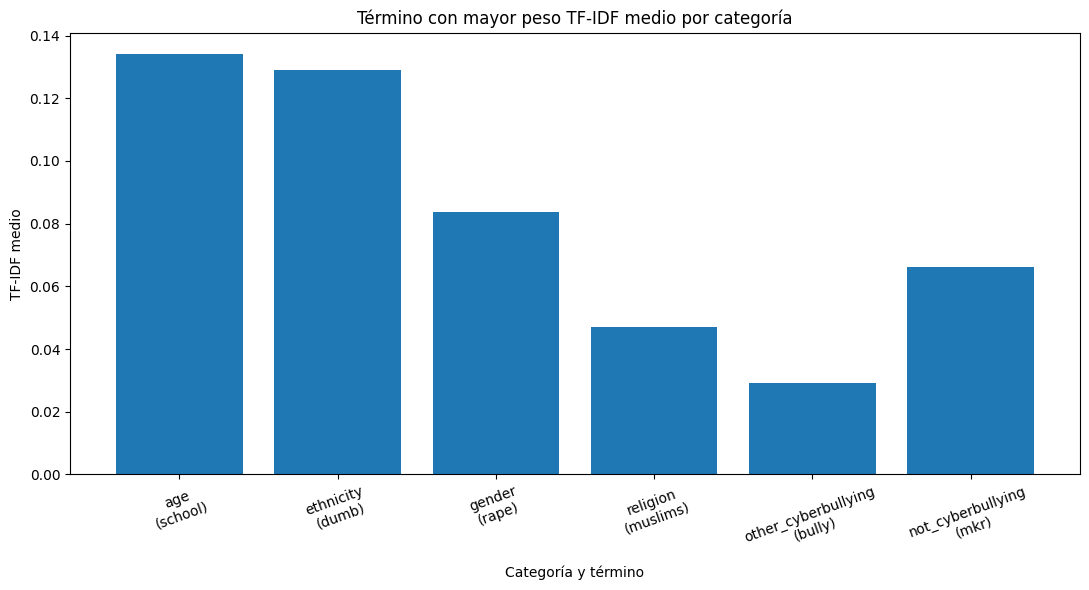

In [43]:
# Creamos una etiqueta que combina
# la categoría y su término más representativo.

df_tfidf_grafico["etiqueta"] = (
    df_tfidf_grafico["categoria"]
    + "\n("
    + df_tfidf_grafico["termino"]
    + ")"
)

# Representamos el peso TF-IDF medio.
plt.figure(figsize=(11, 6))

plt.bar(
    df_tfidf_grafico["etiqueta"],
    df_tfidf_grafico["tfidf_medio"]
)

plt.title(
    "Término con mayor peso TF-IDF medio por categoría"
)

plt.xlabel("Categoría y término")
plt.ylabel("TF-IDF medio")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 12. Conclusiones del Análisis Exploratorio de Datos

El análisis exploratorio permitió estudiar la estructura, calidad y características lingüísticas del dataset antes de iniciar el entrenamiento de los modelos.

El conjunto de datos original contenía 47.692 mensajes distribuidos en seis categorías. No se detectaron valores nulos, aunque sí duplicados e inconsistencias de etiquetado: algunos textos idénticos estaban asociados a categorías diferentes. Para evitar introducir ruido en el aprendizaje supervisado se eliminaron los textos con etiquetas contradictorias y posteriormente los duplicados restantes.

Tras este proceso se obtuvo un dataset final de 44.378 mensajes, lo que supone una reducción del 6,95 % respecto al conjunto original. Las seis categorías mantienen una representación razonablemente equilibrada, aproximadamente entre el 14 % y el 18 %, por lo que inicialmente no se considera necesario aplicar técnicas de balanceo.

El análisis de longitud mostró diferencias entre categorías. Los mensajes relacionados con religión y edad presentan, dentro de este dataset, una longitud media superior a los pertenecientes a las categorías `other_cyberbullying` y `not_cyberbullying`. Esta observación permitirá valorar posteriormente si la longitud del texto puede aportar información adicional al modelo.

El análisis del vocabulario y de los bigramas mostró patrones lingüísticos diferentes entre las categorías específicas. Por ejemplo, en la categoría `age` destacan expresiones relacionadas con el contexto escolar. El análisis mediante TF-IDF confirmó también diferencias en la relevancia relativa del vocabulario utilizado en las distintas categorías.

Las categorías `other_cyberbullying` y `not_cyberbullying` presentan un vocabulario más heterogéneo y menos delimitado temáticamente. Además, se identificaron algunos términos asociados al origen o contexto de recopilación de los mensajes, lo que debe tenerse en cuenta al interpretar la capacidad de generalización de los futuros modelos.

También se observaron mensajes en idiomas diferentes del inglés. Dado que el análisis lingüístico se ha diseñado principalmente para inglés, el carácter parcialmente multilingüe del dataset constituye una limitación y una posible línea de mejora futura.

En conjunto, el EDA muestra que el dataset dispone de suficiente información textual y una distribución adecuada de las clases para abordar un problema de clasificación multiclase mediante técnicas de Procesamiento del Lenguaje Natural y Machine Learning clásico.

El siguiente paso será transformar los textos en características numéricas, construir diferentes modelos de clasificación y comparar su rendimiento mediante métricas adecuadas para un problema multiclase.